# Explore Queens data set

LUBNA ASMI | 06-06-2026 <br>
<br>
This analysis explores NYC 311 service requests from Queens (2024) using Python/Pandas for EDA and SQLite3 for SQL-based queries to uncover complaint patterns, agency response times, and data quality issues.


## EDA with Pandas

In [6]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data Import 

In [3]:
df = pd.read_parquet("queens.parquet")

In [23]:
df.head(5)

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,city,latitude,longitude,response_hours
0,60670513,2024-03-23 13:28:00,2026-04-30 14:40:29,Damaged Tree,Branch Cracked and Will Fall,QUEENS,DPR,Department of Parks and Recreation,Closed,11426,BELLEROSE,40.740512921350295,-73.71936242070576,18433.208056
1,60559674,2024-03-12 21:02:24,2026-05-03 18:00:11,Dead/Dying Tree,Planted More Than 2 Years Ago,QUEENS,DPR,Department of Parks and Recreation,Closed,11426,BELLEROSE,40.72488549606099,-73.72790299075211,18764.963056
2,60485790,2024-03-04 08:01:55,2026-05-01 18:29:16,Damaged Tree,Tree Alive - in Poor Condition,QUEENS,DPR,Department of Parks and Recreation,Closed,11427,QUEENS VILLAGE,40.72443346928045,-73.74631178348649,18922.455833
3,60983820,2024-04-26 14:07:55,2026-05-05 12:26:10,Dead/Dying Tree,Planted More Than 2 Years Ago,QUEENS,DPR,Department of Parks and Recreation,Closed,11354,None,40.77418620877768,-73.81297752879395,17734.304167
4,61626369,2024-06-27 17:26:58,2026-04-25 13:18:58,Damaged Tree,Entire Tree Has Fallen Down,QUEENS,DPR,Department of Parks and Recreation,Closed,11428,QUEENS VILLAGE,40.718919093791676,-73.73647710651454,16003.866667


### Data Cleaning & Quality Analysis 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 827070 entries, 0 to 827069
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   unique_key      827070 non-null  object        
 1   created_date    827070 non-null  datetime64[ns]
 2   closed_date     811130 non-null  datetime64[ns]
 3   complaint_type  827070 non-null  object        
 4   descriptor      821975 non-null  object        
 5   borough         827070 non-null  object        
 6   agency          827070 non-null  object        
 7   agency_name     827070 non-null  object        
 8   status          827070 non-null  object        
 9   incident_zip    818202 non-null  object        
 10  city            780285 non-null  object        
 11  latitude        808025 non-null  object        
 12  longitude       808025 non-null  object        
 13  response_hours  811130 non-null  float64       
dtypes: datetime64[ns](2), float64(1), ob

The dataset contains 14 columns with mixed data types:

- `created_date` and `closed_date` are in `datetime64` format.
- `response_hours` is  `float64`, representing the time difference between `created_date` and `closed_date` in hours.
- All remaining columns (`complaint_type`, `agency`, `status`, `incident_zip`, etc.) are stored as `object`type.

**Note:** The downloaded parquet file differs from the original NYC Open Data schema. 
The raw API contains additional columns (e.g., `incident_address`, `street_name`, 
`cross_street_1`etc ) and stores dates as `floating_timestamp`. The pre-processed parquet file used here converts dates to `datetime64`, adds a pre-calculated `response_hours` column, and retains only the 14 most relevant columns for this analysis.

In [44]:
# Checking null 
df.isnull().sum()

unique_key            0
created_date          0
closed_date       15940
complaint_type        0
descriptor         5095
borough               0
agency                0
agency_name           0
status                0
incident_zip       8868
city              46785
latitude          19045
longitude         19045
response_hours    15940
dtype: int64

`closed_date` null (15,940 rows) --- those requests are still open/pending.<br>
`descriptor` null (5,095 rows) --- since it has no harm , no need of dropping.<br>
`incident_zip` null (8,868 rows) --- flaging- data quality issue <br>
`city null` (46,785 rows) <br>
`latitude/longitude` null (19,045 rows) -- only matters if mapping<br>
`response_hours` null (15940 rows) -- since 15,940 are still pending.

In [28]:
#Checking
df[df['response_hours'].isnull()]

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,city,latitude,longitude,response_hours
8,63022306,2024-11-08 21:44:25,NaT,Damaged Tree,Branch or Limb Has Fallen Down,QUEENS,DPR,Department of Parks and Recreation,In Progress,11419,SOUTH RICHMOND HILL,40.685616369631525,-73.82577010770048,NaN
12,61919573,2024-07-25 19:31:10,NaT,Illegal Tree Damage,Branches Damaged,QUEENS,DPR,Department of Parks and Recreation,In Progress,11420,SOUTH OZONE PARK,40.667189679377394,-73.81804293390006,NaN
24,62503391,2024-09-19 11:49:41,NaT,Overgrown Tree/Branches,Hitting Building,QUEENS,DPR,Department of Parks and Recreation,In Progress,11366,FRESH MEADOWS,40.73227922319016,-73.78464081541681,NaN
211,62615345,2024-09-30 14:17:00,NaT,Street Light Condition,Lamppost Leaning,QUEENS,DOT,Department of Transportation,Assigned,11420,QUEENS,40.679602337541546,-73.80348308158008,NaN
220,63197791,2024-11-24 10:20:33,NaT,Overgrown Tree/Branches,Hitting Building,QUEENS,DPR,Department of Parks and Recreation,In Progress,11426,BELLEROSE,40.744697782133215,-73.71899112133019,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827001,63545699,2024-12-28 16:34:26,NaT,Noise - Helicopter,Other,QUEENS,EDC,Economic Development Corporation,In Progress,11414,HOWARD BEACH,40.66691551071256,-73.84243287868425,NaN
827003,63544727,2024-12-28 17:02:00,NaT,Noise - Helicopter,Other,QUEENS,EDC,Economic Development Corporation,In Progress,11414,HOWARD BEACH,40.66749891300168,-73.84353814355593,NaN
827005,63558774,2024-12-29 22:11:45,NaT,Noise - Helicopter,Other,QUEENS,EDC,Economic Development Corporation,In Progress,11104,SUNNYSIDE,40.74800505166298,-73.91678610390865,NaN
827019,63541623,2024-12-28 16:10:03,NaT,Noise - Helicopter,Other,QUEENS,EDC,Economic Development Corporation,In Progress,11414,HOWARD BEACH,40.66850742742437,-73.84852115365172,NaN


In [22]:
df.describe()

,created_date,closed_date,response_hours
count,827070,811130,811130.000000
mean,2024-07-04 01:33:09.303949824,2024-07-18 11:20:33.377603840,347.070082
min,2024-01-01 00:00:46,2023-02-22 10:15:00,-8784.016667
25%,2024-04-08 15:24:03,2024-04-15 02:37:56.249999872,1.096944
50%,2024-07-03 22:51:39,2024-07-14 13:45:00,5.619722
75%,2024-09-29 15:19:40.249999872,2024-10-12 17:25:33.750000128,51.658819
max,2024-12-31 23:59:03,2026-06-03 00:00:00,20496.833333
std,NaN,NaN,1367.896294



min is  -8784.016667 <br>
negative value means closed_date is before created_date, which is impossible in reality. It's a data quality issue.

In [45]:
#Checking for  negatives
df[df['response_hours'] < 0]
#print(f"Rows with negative response_hours: {(df['response_hours'] < 0).sum()}")

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,city,latitude,longitude,response_hours
5050,60302715,2024-02-12 09:58:00,2024-02-09 09:57:00,Street Light Condition,Street Light Out,QUEENS,DOT,Department of Transportation,Pending,None,None,None,None,-72.016667
5134,60404036,2024-02-23 14:50:00,2023-06-27 14:50:00,Street Light Condition,Street Light Out,QUEENS,DOT,Department of Transportation,Pending,None,None,None,None,-5784.000000
5989,61432446,2024-06-10 09:43:00,2024-06-07 09:43:00,Street Light Condition,Fixture/Luminaire Door Open,QUEENS,DOT,Department of Transportation,Pending,None,None,None,None,-72.000000
8121,59901032,2024-01-02 10:17:00,2023-12-28 10:16:00,Street Light Condition,Multiple Street Lights Out,QUEENS,DOT,Department of Transportation,Pending,11374,QUEENS,40.72412012824127,-73.85561748802189,-120.016667
18088,59941948,2024-01-05 09:39:00,2024-01-04 09:38:00,Street Light Condition,Multiple Street Lights Out,QUEENS,DOT,Department of Transportation,Pending,None,None,None,None,-24.016667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814486,63538538,2024-12-26 08:28:03,2024-12-26 01:25:00,Street Condition,Pothole,QUEENS,DOT,Department of Transportation,Closed,11432,QUEENS,40.7178507559494,-73.79559990750063,-7.050833
814808,63536090,2024-12-26 08:30:11,2024-12-26 02:10:00,Street Condition,Pothole,QUEENS,DOT,Department of Transportation,Closed,None,None,None,None,-6.336389
816663,63537331,2024-12-26 08:29:02,2024-12-26 01:40:00,Street Condition,Pothole,QUEENS,DOT,Department of Transportation,Closed,11432,QUEENS,None,None,-6.817222
820935,63565033,2024-12-30 09:11:00,2024-12-27 09:11:00,Street Light Condition,Multiple Street Lights Out,QUEENS,DOT,Department of Transportation,Pending,11427,QUEENS,40.729261932449006,-73.75281314881637,-72.000000


Total 402 rows are showing negative response time.

In [48]:
# Finding agency/counts for -ve response time
df[df['response_hours'] < 0]['agency'].value_counts()

agency
DOT     383
NYPD     19
Name: count, dtype: int64

**Data Quality Issue, Negative Response Times:**
402 rows have negative `response_hours`,  `closed_date`. These are mostly DOT complaints(min NYPD). This likely reflects a data entry or system logging error 
specific to DOT. 

In [41]:
#Checking NYPD negative issue
df[(df['response_hours'] < 0) & (df['agency'] == 'NYPD')]

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,city,latitude,longitude,response_hours
695884,62956764,2024-11-03 01:44:49,2024-11-03 01:27:30,Noise - Residential,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11412,SAINT ALBANS,40.70017085845152,-73.76497024453222,-0.288611
696992,62956398,2024-11-03 01:56:38,2024-11-03 01:50:16,Blocked Driveway,No Access,QUEENS,NYPD,New York City Police Department,Closed,11385,RIDGEWOOD,40.69547269822946,-73.89304708267466,-0.106111
697904,62960882,2024-11-03 01:50:13,2024-11-03 01:28:18,Noise - Residential,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11423,HOLLIS,40.71740780496812,-73.76218586911996,-0.365278
697929,62960857,2024-11-03 01:48:10,2024-11-03 01:27:32,Noise - Residential,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11692,ARVERNE,40.59209790098616,-73.78781859628411,-0.343889
697965,62965835,2024-11-03 01:29:17,2024-11-03 01:10:32,Noise - Residential,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11412,SAINT ALBANS,40.69436516196884,-73.76205890182338,-0.312500
698002,62960743,2024-11-03 01:46:06,2024-11-03 01:13:47,Noise - Residential,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11385,RIDGEWOOD,40.69683628198926,-73.90490956720313,-0.538611
698462,62956645,2024-11-03 01:22:25,2024-11-03 01:10:00,Noise - Commercial,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11434,JAMAICA,40.68187089534303,-73.7660623046722,-0.206944
698807,62960791,2024-11-03 01:43:35,2024-11-03 01:12:36,Noise - Residential,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11412,SAINT ALBANS,40.70017085845152,-73.76497024453222,-0.516389
698888,62965954,2024-11-03 01:33:33,2024-11-03 01:16:04,Noise - Residential,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11419,SOUTH RICHMOND HILL,40.69216773847551,-73.81495651667441,-0.291389
698924,62964719,2024-11-03 01:28:09,2024-11-03 01:26:56,Noise - Residential,Loud Music/Party,QUEENS,NYPD,New York City Police Department,Closed,11366,FRESH MEADOWS,40.7280999962898,-73.79268930020204,-0.020278


**NYPD Negative Response Times, Daylight Saving Time:**
All 19 NYPD rows with negative `response_hours` occurred on November 3,  the night clocks fell back for Daylight Saving Time. The small negative values (all under 1 hour) suggest a timezone handling issue in the logging system, not a true data error. 

In [42]:
# dropping those negative response_hours from data set

df_clean = df[df['response_hours'] >= 0]

In [58]:
# loading clean dataset
df_clean.head(3)

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,city,latitude,longitude,response_hours
0,60670513,2024-03-23 13:28:00,2026-04-30 14:40:29,Damaged Tree,Branch Cracked and Will Fall,QUEENS,DPR,Department of Parks and Recreation,Closed,11426,BELLEROSE,40.740512921350295,-73.71936242070576,18433.208056
1,60559674,2024-03-12 21:02:24,2026-05-03 18:00:11,Dead/Dying Tree,Planted More Than 2 Years Ago,QUEENS,DPR,Department of Parks and Recreation,Closed,11426,BELLEROSE,40.72488549606099,-73.72790299075211,18764.963056
2,60485790,2024-03-04 08:01:55,2026-05-01 18:29:16,Damaged Tree,Tree Alive - in Poor Condition,QUEENS,DPR,Department of Parks and Recreation,Closed,11427,QUEENS VILLAGE,40.72443346928045,-73.74631178348649,18922.455833


In [ ]:
# checking year == 2024
print(df_clean['created_date'].dt.year.value_counts())

created_date
2024    810728
Name: count, dtype: int64


Only 2024 data is present, no filtering needed

## Analytical Questions

### 1.  What are the top 10 most common complaint types (complaint_type) across the full dataset?

In [55]:
 top10 = df_clean['complaint_type'].value_counts().head(10)
 top10

complaint_type
Illegal Parking            149760
Blocked Driveway            71741
Noise - Residential         69593
HEAT/HOT WATER              36711
Abandoned Vehicle           28353
Noise - Street/Sidewalk     25125
Street Condition            24105
Water System                17791
Drug Activity               17731
UNSANITARY CONDITION        17640
Name: count, dtype: int64



The top 10 most common complaint types in Queens (2024) show that Illegal Parking 
dominates service requests, making it the single biggest concern for residents. 
This reflects the chronic parking pressure in Queens, where high car ownership 
meets limited street space. Noise complaints and other quality-of-life issues 
follow closely behind.

### 2. Which borough generates the most service requests? Does the distribution surprise you?

In [57]:
df_clean['borough'].value_counts()

borough
QUEENS    810728
Name: count, dtype: int64



Since this analysis uses the Queens-specific dataset, all 810,728 records 
(after removing negative response times) belong to Queens.

### 3. What is the average resolution time (in days) by agency? Use created_date and closed_date to calculate. Which agency resolves requests fastest and which is slowest?

`response_hours` was pre-calculated from `created_date` and `closed_date`, 
so it is used directly here and converted to days by dividing by 24.

In [ ]:
# creating a new column
df_clean['response_hours_days'] = df_clean['response_hours'].apply(lambda x:x/24)

/var/folders/q5/2q5fx7g95dz8n7ybspx1lw8r0000gp/T/ipykernel_6754/2790141335.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['response_hours_days'] = df_clean['response_hours'].apply(lambda x:x/24)


In [70]:
df_clean.head(3)

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,city,latitude,longitude,response_hours,response_hours_days
0,60670513,2024-03-23 13:28:00,2026-04-30 14:40:29,Damaged Tree,Branch Cracked and Will Fall,QUEENS,DPR,Department of Parks and Recreation,Closed,11426,BELLEROSE,40.740512921350295,-73.71936242070576,32.002097,1.333421
1,60559674,2024-03-12 21:02:24,2026-05-03 18:00:11,Dead/Dying Tree,Planted More Than 2 Years Ago,QUEENS,DPR,Department of Parks and Recreation,Closed,11426,BELLEROSE,40.72488549606099,-73.72790299075211,32.578061,1.357419
2,60485790,2024-03-04 08:01:55,2026-05-01 18:29:16,Damaged Tree,Tree Alive - in Poor Condition,QUEENS,DPR,Department of Parks and Recreation,Closed,11427,QUEENS VILLAGE,40.72443346928045,-73.74631178348649,32.851486,1.368812


In [68]:
avg_resolution = df_clean.groupby('agency_name')['response_hours_days'].mean().sort_values()
print(avg_resolution)

agency_name
New York City Police Department                       0.000242
Department of Homeless Services                       0.006662
Department of Sanitation                              0.007073
Department of Environmental Protection                0.010220
Office of Technology and Innovation                   0.015649
Department of Housing Preservation and Development    0.021228
Department of Transportation                          0.023197
Department of Consumer and Worker Protection          0.029483
Department of Health and Mental Hygiene               0.084468
Department of Education                               0.093147
Economic Development Corporation                      0.097874
Taxi and Limousine Commission                         0.135576
Department of Buildings                               0.175216
Department of Parks and Recreation                    0.204209
Name: response_hours_days, dtype: float64




 The NYPD resolves requests fastest  at under a minute on average largely. 

Department of Parks and Recreation is the slowest at 0.20 days,  followed by Department of Buildings (~0.18 days).

Overall, resolution times across all agencies are surprisingly fast, with most closing requests within hours rather than days.

### 4. Are there any complaint types that appear to be seasonal or concentrated in certain timeperiods? Use created_date to group by month. Show your evidence.

In [72]:
#Extracting months

df_clean['month']= df_clean['created_date'].dt.month

/var/folders/q5/2q5fx7g95dz8n7ybspx1lw8r0000gp/T/ipykernel_6754/2556749620.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['month']= df_clean['created_date'].dt.month


In [ ]:
# counting number of rows in group(month & complaint_type)
seasonal = df_clean.groupby(['month', 'complaint_type']).size().reset_index(name = 'count')
seasonal

,month,complaint_type,count
0,1,APPLIANCE,259
1,1,Abandoned Bike,21
2,1,Abandoned Vehicle,2290
3,1,Adopt-A-Basket,2
4,1,Air Quality,219
...,...,...,...
1736,12,Water Conservation,80
1737,12,Water Quality,32
1738,12,Water System,1664
1739,12,Window Guard,1


In [84]:
# Check heat-related complaints by month
seasonal[seasonal['complaint_type'] == 'HEAT/HOT WATER'].sort_values('month')

,month,complaint_type,count
52,1,HEAT/HOT WATER,7844
195,2,HEAT/HOT WATER,4234
333,3,HEAT/HOT WATER,3637
475,4,HEAT/HOT WATER,2313
622,5,HEAT/HOT WATER,834
767,6,HEAT/HOT WATER,438
916,7,HEAT/HOT WATER,397
1066,8,HEAT/HOT WATER,403
1213,9,HEAT/HOT WATER,355
1359,10,HEAT/HOT WATER,2359


In [85]:
# Check noise complaints by month
seasonal[seasonal['complaint_type'] == 'Noise - Residential'].sort_values('month')

,month,complaint_type,count
85,1,Noise - Residential,4235
228,2,Noise - Residential,4346
366,3,Noise - Residential,5140
509,4,Noise - Residential,5290
658,5,Noise - Residential,6662
802,6,Noise - Residential,7999
953,7,Noise - Residential,6203
1102,8,Noise - Residential,6042
1248,9,Noise - Residential,7373
1394,10,Noise - Residential,6286


In [ ]:
top_complaints = df_clean['complaint_type'].value_counts().head(5).index
#top_complaints 
seasonal_top = seasonal[seasonal['complaint_type'].isin(top_complaints)]
seasonal_top

,month,complaint_type,count
2,1,Abandoned Vehicle,2290
12,1,Blocked Driveway,6308
52,1,HEAT/HOT WATER,7844
62,1,Illegal Parking,11886
85,1,Noise - Residential,4235
144,2,Abandoned Vehicle,2121
154,2,Blocked Driveway,5655
195,2,HEAT/HOT WATER,4234
206,2,Illegal Parking,11367
228,2,Noise - Residential,4346


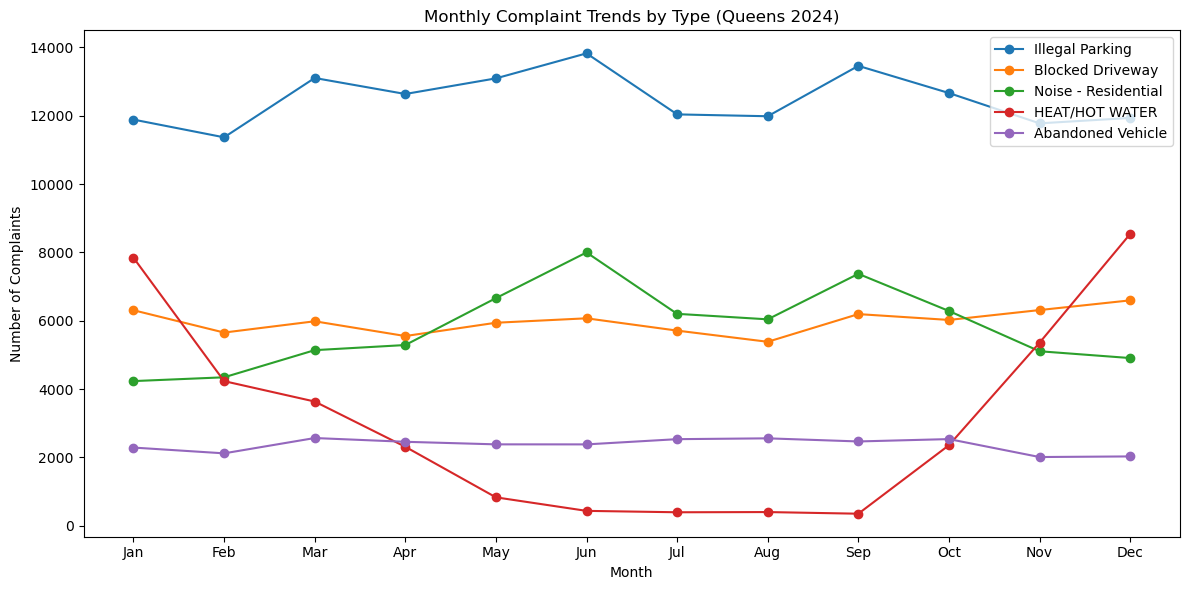

In [ ]:

plt.figure(figsize=(12, 6))
for complaint in top_complaints:
    data = seasonal_top[seasonal_top['complaint_type'] == complaint] # filters the table to only that complaint's rows 
    plt.plot(data['month'], data['count'], marker='o', label=complaint)

plt.title('Monthly Complaint Trends by Type (Queens 2024)')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.show()



The data shows clear seasonal trends for certain complaint types:

- **HEAT/HOT WATER** is highly seasonal,  peaking in winter months 
  (January: 7,844, December: 8,539) and dropping sharply in summer 
  (June: 438, July: 397). This makes sense as heating systems are only 
  needed in cold months.

- **Noise Residential** peaks in summer (June: 7,999, September: 7,373) 
  and drops in winter (January: 4,235, December: 4,909). Warmer weather 
  means more outdoor activity and open windows, leading to more noise complaints.

- **Illegal Parking** and **Blocked Driveway** remain relatively consistent 
  year-round, suggesting these are chronic issues not tied to any season.


### 5. Identify at least one data quality issue in the dataset. How did you handle it?

In [97]:
# Check missing values
print(df_clean.isnull().sum())


unique_key                 0
created_date               0
closed_date                0
complaint_type             0
descriptor              1890
borough                    0
agency                     0
agency_name                0
status                     0
incident_zip            7591
city                   44949
latitude               17713
longitude              17713
response_hours             0
response_hours_days        0
month                      0
dtype: int64


In [104]:
# Check invalid zip codes
print(df_clean['incident_zip'].value_counts())



incident_zip
11385    42165
11368    35829
11101    31008
11377    30822
11373    26247
         ...  
11371       22
11237       13
11208        9
11695        5
11021        2
Name: count, Length: 69, dtype: int64


#### `incident_zip`

In [ ]:
# Check all zip codes are exactly 5 digits, no invalid lengths and not null
invalid_zip = df_clean[df_clean['incident_zip'].notnull() & (df_clean['incident_zip'].str.len() != 5)]
print(invalid_zip)
print(f"Invalid zip codes: {len(invalid_zip)}")


Empty DataFrame
Columns: [unique_key, created_date, closed_date, complaint_type, descriptor, borough, agency, agency_name, status, incident_zip, city, latitude, longitude, response_hours, response_hours_days, month]
Index: []
Invalid zip codes: 0



7591 rows have null `incident_zip` values. However, all non-null zip codes are valid 5-digit format no malformed entries were found.


**How it was handled:** Missing zip codes were left as null and not dropped, 
since zip code is not a primary variable in this analysis. Borough-level 
information is available for all rows and was used instead for location-based 
analysis.

#### `response_hours`

In [112]:
# Check negative response times (already analysed)
print(f"Negative response times: {(df['response_hours'] < 0).sum()}")


Negative response times: 402



**How it was handled:** A cleaned dataframe `df_clean` was created by 
excluding all 402 rows with negative response times. This represents only 
0.05% of the dataset, so the impact on analysis is minimal.

#### `closed_date` & `status`

In [ ]:
# Check open cases with a closed date
df_new = df[(df['status'] == 'Open') & (df['closed_date'].notnull())] #if closed_date has a value 
df_new.head(3)


,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,city,latitude,longitude,response_hours
5433,60737581,2024-03-30 20:02:50,2024-03-30 20:02:50,General Construction/Plumbing,Fence - None/Inadequate,QUEENS,DOB,Department of Buildings,Open,11358,FLUSHING,40.76055371725162,-73.79252692360451,0.0
7025,63212349,2024-11-26 15:37:23,2024-11-26 15:37:23,General Construction/Plumbing,Fence - None/Inadequate,QUEENS,DOB,Department of Buildings,Open,11415,KEW GARDENS,40.70314135452914,-73.82732925551039,0.0
22225,59965763,2024-01-08 19:02:02,2024-01-08 19:02:02,General Construction/Plumbing,"Building - Vacant, Open And Unguarded",QUEENS,DOB,Department of Buildings,Open,11414,HOWARD BEACH,40.669006023568144,-73.85200584492385,0.0


In [121]:
print(f"Status='Open' but has closed_date: {len(df_new)}")

Status='Open' but has closed_date: 637



637 rows have `status = 'Open'` but also have a `closed_date` recorded,  a logical contradiction. A case cannot be open and closed at the same time. Additionally, many of these rows show identical `created_date` and `closed_date` 
timestamps, suggesting the closing date was auto-populated at creation rather than when the case was actually resolved. 

**How it was handled:** These rows were flagged but kept in 
the dataset, as they represent a system logging issue rather than invalid records.

## Visualization

### Chart 1 - Top 10 Complaint Types:

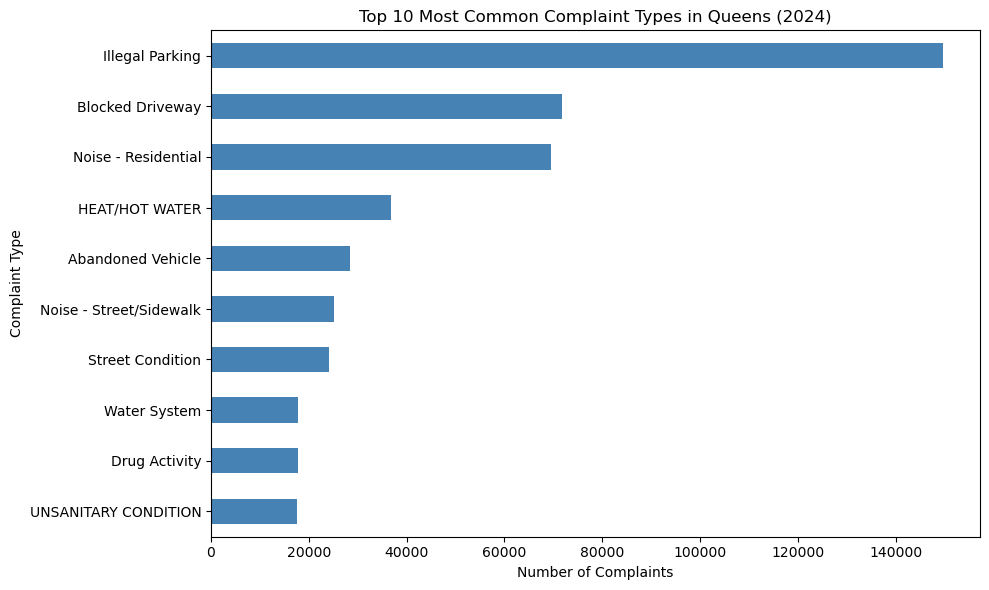

In [123]:
import matplotlib.pyplot as plt

top10 = df_clean['complaint_type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Common Complaint Types in Queens (2024)')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.tight_layout()
plt.show()

Illegal Parking dominates Queens 311 complaints in 2024, followed by Blocked 
Driveway and HEAT/HOT WATER. This highlights parking and housing conditions 
as the city's most pressing quality-of-life issues.

### Chart 2 - Resolution Time by Agency:

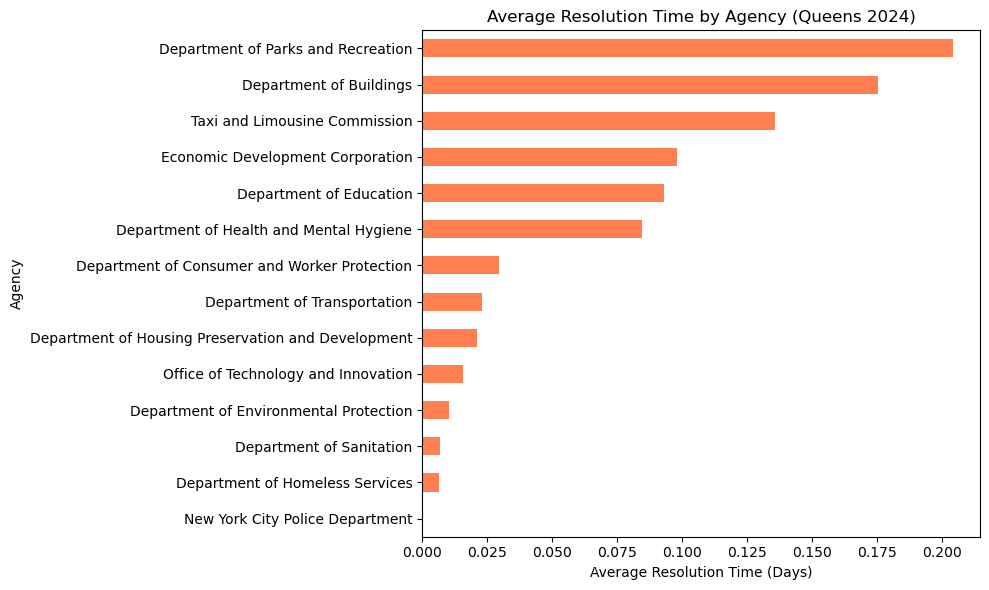

In [124]:
plt.figure(figsize=(10, 6))
avg_resolution.plot(kind='barh', color='coral')
plt.title('Average Resolution Time by Agency (Queens 2024)')
plt.xlabel('Average Resolution Time (Days)')
plt.ylabel('Agency')
plt.tight_layout()
plt.show()

NYPD resolves complaints nearly instantly while the Department of Parks and 
Recreation takes the longest. This reflects the nature of each agency's work,
police close noise calls quickly while park maintenance requires scheduled visits.

### Chart 3 - Top 10 Zip Codes by Complaint Volume:

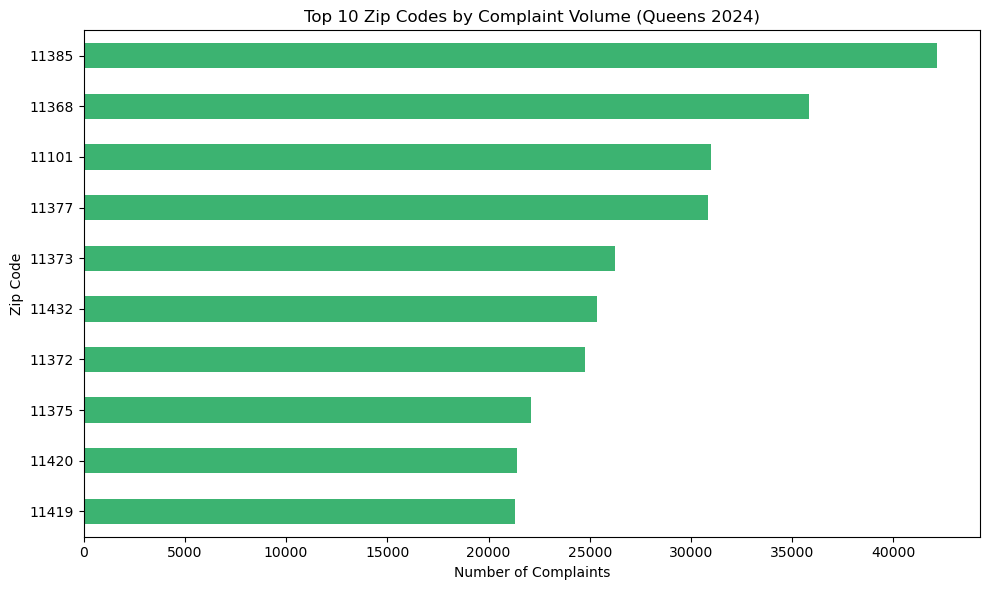

In [126]:
top_zips = df_clean['incident_zip'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_zips.sort_values().plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Zip Codes by Complaint Volume (Queens 2024)')
plt.xlabel('Number of Complaints')
plt.ylabel('Zip Code')
plt.tight_layout()
plt.show()

Certain zip codes (11385,11368 ..)in Queens generate significantly more 311 complaints than 
others (11420,11419..), suggesting that resources and city services may need to be concentrated 
in these high-demand neighborhoods.

## SQLite3 in Python

In [135]:
import sqlite3

# 1. Create a local SQLite database file
conn = sqlite3.connect('queens.db')

# 2. Load dataframe into it as a table called 'queens'
df_clean.to_sql('queens', conn, index=False, if_exists='replace')

810728

In [136]:
pd.read_sql_query("SELECT * FROM queens LIMIT 5", conn)

,unique_key,created_date,closed_date,complaint_type,descriptor,borough,agency,agency_name,status,incident_zip,city,latitude,longitude,response_hours,response_hours_days,month
0,60670513,2024-03-23 13:28:00,2026-04-30 14:40:29,Damaged Tree,Branch Cracked and Will Fall,QUEENS,DPR,Department of Parks and Recreation,Closed,11426,BELLEROSE,40.740512921350295,-73.71936242070576,32.002097,1.333421,3
1,60559674,2024-03-12 21:02:24,2026-05-03 18:00:11,Dead/Dying Tree,Planted More Than 2 Years Ago,QUEENS,DPR,Department of Parks and Recreation,Closed,11426,BELLEROSE,40.72488549606099,-73.72790299075211,32.578061,1.357419,3
2,60485790,2024-03-04 08:01:55,2026-05-01 18:29:16,Damaged Tree,Tree Alive - in Poor Condition,QUEENS,DPR,Department of Parks and Recreation,Closed,11427,QUEENS VILLAGE,40.72443346928045,-73.74631178348649,32.851486,1.368812,3
3,60983820,2024-04-26 14:07:55,2026-05-05 12:26:10,Dead/Dying Tree,Planted More Than 2 Years Ago,QUEENS,DPR,Department of Parks and Recreation,Closed,11354,None,40.77418620877768,-73.81297752879395,30.788723,1.282863,4
4,61626369,2024-06-27 17:26:58,2026-04-25 13:18:58,Damaged Tree,Entire Tree Has Fallen Down,QUEENS,DPR,Department of Parks and Recreation,Closed,11428,QUEENS VILLAGE,40.718919093791676,-73.73647710651454,27.784491,1.157687,6


#### Question 1: What is the overall distribution of case statuses in Queens 2024?


In [139]:
# This shows how effectively the city resolves 311 complaints.

q1 = pd.read_sql_query("""
    SELECT status, COUNT(*) as total
    FROM queens
    GROUP BY status
    ORDER BY total DESC
""", conn)
print(q1)

        status   total
0       Closed  809551
1         Open     637
2     Assigned     529
3  Unspecified       8
4      Started       2
5      Pending       1



Over 99.9% of Queens 311 complaints in 2024 were closed, with only 637 open and 529 assigned cases remaining. This suggests strong overall resolution rates, though the 637 open cases with recorded closed dates (found earlier) indicate 
some data integrity issues in status tracking.

#### Question 2: How many complaints did each agency handle?

In [ ]:

q1 = pd.read_sql_query("""
    SELECT agency_name, COUNT(*) as total
    FROM queens
    GROUP BY agency_name
    ORDER BY total DESC
""", conn)
print(q1)

                                          agency_name   total
0                     New York City Police Department  417102
1   Department of Housing Preservation and Develop...   97123
2                            Department of Sanitation   78588
3                        Department of Transportation   62987
4              Department of Environmental Protection   51195
5                  Department of Parks and Recreation   37703
6                             Department of Buildings   27269
7             Department of Health and Mental Hygiene   17096
8                    Economic Development Corporation    7655
9                       Taxi and Limousine Commission    6011
10       Department of Consumer and Worker Protection    4663
11                    Department of Homeless Services    2830
12                            Department of Education     478
13                Office of Technology and Innovation      28



The NYPD handles by far the most 311 complaints in Queens (417,102), nearly 4x more than the next agency (Housing Preservation at 97,123). This reflects how many quality-of-life complaints : noise, parking, blocked driveways -
fall under police jurisdiction.

_________________________________________________________________________________________________

## Insight Brief: Queens 311 Service Requests (2024)

**What I looked at and why**
This analysis examined over 800,000 non-emergency service requests (311 calls) made by Queens residents in 2024. The goal was to understand what residents complain about most, how quickly the city responds, and whether any patterns 
or problems stand out that the city could act on.

**Key findings**

1. **Illegal parking dominates, and the NYPD carries the load.** Illegal parking is the single most common complaint in Queens, and the NYPD alone handles 417,102 complaints, nearly 4x more than the next agency (Housing Preservation- 97,123). This shows how much of the city's quality-of-life workload (noise, parking, blocked driveways) falls on police rather than specialized agencies.

2. **Complaints cluster heavily in specific zip codes.** Areas like 11385 and 11368 generate far more complaints than others like 11420 and 11419 - suggesting the city could concentrate enforcement and services in these high-demand neighborhoods rather than spreading resources evenly.

3. **Resolution looks strong on paper, but the data has gaps.** Over 99.9% of complaints were marked "closed," yet 637 cases were simultaneously labeled "Open" while having a recorded closing date — a contradiction that suggests 
the city's status-tracking system needs cleanup before its numbers can be fully trusted.

4. **Response times vary dramatically by agency.** The NYPD closes most complaints in under a minute on average, while 
the Department of Parks and Recreation takes roughly five hours- understandable, since park issues require an in-person visit rather than a quick dispatch.

5. **Complaints follow clear seasonal cycles.** Heat/hot water complaints spike sharply in winter (peaking near 8,500 in December) and nearly disappear in summer, while noise complaints do the opposite,peaking in summer when 
windows are open and people are outside more.



 ### Recommendation


1. Fix the slow agencies:

The Department of Parks and Recreation and Department of Buildings take the
longest to resolve complaints (multiple hours on average, compared to NYPD's
near-instant response). The city should investigate whether this gap is due
to staffing shortages or scheduling inefficiencies, and consider reallocating
resources so residents aren't waiting disproportionately long for non-police
issues like building safety and park maintenance.

2. Target the #1 complaint directly:

Since illegal parking is the single most common complaint in Queens - and
remains high across all months - the city should pilot increased parking
enforcement in the top complaint zip codes identified in this analysis
(e.g., 11385, 11368, 11101). A geographically targeted approach would likely
reduce complaint volume more efficiently than city-wide measures.

3. Create Specialized Civilian Response Teams

With the NYPD currently absorbing the vast majority of 311 complaints- many 
of which are non-criminal quality-of-life issues like noise and parking, the 
city should consider routing certain complaint types to specialized civilian 
units instead. For example, noise complaints could go to a dedicated 
quality-of-life response team, freeing up police resources for higher-priority 
matters while still ensuring residents' concerns are addressed promptly. 

----------------------------------------------------------------------------------------------------------

## Reflection




One thing this dataset can't tell me is why residents file certain complaints 
or whether the resolution actually solved the underlying problem. For example, 
I can see that a noise complaint was "closed," but I can't tell if the noise 
actually stopped, if the resident was satisfied, or if they had to call again. 
The data tells me what happened administratively (a case was opened and closed), 
not whether it made a real difference in someone's life.

I'd also want to compare this 2024 data against 2025 (and beyond) to see 
whether high-volume issues like illegal parking are increasing, decreasing, or 
staying flat year over year. If a problem like illegal parking keeps growing 
despite being the most-reported complaint, that would raise an important 
question: what measures is the city actually taking to address it, and are 
they working? Without multi-year trend data, I can't tell if the city is 
making progress or just processing the same recurring problem on repeat.

Additional data that would change my analysis:
- **Multi-year data (2023-2025)** - to track whether top complaints like illegal parking are trending up, down, or staying constant<br>

- **Repeat complaints from the same address/resident** - to see if the same issue keeps recurring despite being "resolved"<br>

- **A satisfaction column captured after a case is closed** - a simple rating or follow-up question asking the resident "Was this resolved to your satisfaction?" This single addition would let the city measure real-world outcomes instead of just administrative closure, and could reveal which agencies close cases quickly but don't actually fix the problem.<br>

- **Resident demographic or housing-type context (e.g., senior living, )** - knowing whether a complaint came from a senior living facility or vulnerable population could help the city auto-flag those cases as higher priority. For example, a heating complaint from a senior living building in winter should arguably be triaged faster than a routine street-light complaint. This kind of contextual data could enable smarter,needs-based prioritization rather than treating every complaint equally.<br>



**With this data, I could move from "what are people complaining about" to "is the city actually solving these problems over time",  which is the question residents and council members likely care about most.**

________________________________________________________________________________________________________